# QHAT L-sweep → fermionic tensors → noncommutation colors → Trotter error

This notebook uses QHAT output directly and does **not** import OpenFermion. It can:

1. call `build_config_L_sweep.py` and `hamgen.py` to generate multiple bond lengths and active spaces;
2. inspect QHAT's `.tensors.npz` one- and two-body arrays (the fermionic coefficient data);
3. parse a mapped JW/BK `.dat` Hamiltonian;
4. build and color its Pauli noncommutation graph; and
5. compare first- and second-order product formulas with exact time evolution.

Important: `.dat` contains the **mapped Pauli Hamiltonian**, while QHAT saves the pre-mapping active-space Hamiltonian as coefficient tensors. This notebook reconstructs both graph views: it canonicalizes and combines normal-ordered tensor monomials before Hermitian pairing to match the convention in `h2_fermionic.ipynb`, and it treats each mapped Pauli string as a vertex for the direct JW comparison. No OpenFermion import is required.

> **Saved-output note:** some earlier full-library output cells were produced with the legacy raw tensor-slot vertex convention. Rerun those cells before using their fermionic vertex/edge counts. The generated files under `trotter_benchmark_results/` and the focused section at the end use the corrected canonical convention.

In [27]:
from pathlib import Path
import subprocess, sys, re
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.linalg import expm, norm

REPO = Path.cwd().resolve()
if not (REPO / 'hamiltonian_generator').is_dir():
    raise RuntimeError('Start this notebook from the QHAT repository root')
OUTPUT_ROOT = REPO / 'demo_L_sweep_library'
print('Repository:', REPO)
print('Sweep output:', OUTPUT_ROOT)

Repository: /Users/albertlee0125/Repos/qhat
Sweep output: /Users/albertlee0125/Repos/qhat/demo_L_sweep_library


## 1. Generate QHAT data

Set `RUN_GENERATION=True` when ready. The conservative demo below requests H–H, 3 bond lengths, both QHAT bases, JW and BK, and every active-space size up to 8 qubits. Increase `L_STEPS` or `MAX_ACTIVE` gradually: exact matrix Trotter-error calculations later scale as $2^n$.

The builder supports hydrides `X-H` and homonuclear diatomics `X-X`; it does not generate arbitrary polyatomic molecules. Examples: `H-H`, `Li-H`, `Li-Li`, or `H-H,He-H,He-He,Li-H,Li-Li`.

In [28]:
RUN_GENERATION = False  # change to True to run PySCF/QHAT
# Any comma-separated subset of the sweep library works, for example:
# 'H-H', 'H-H,Li-H,Li-Li', or all nine names listed below.
MOLECULES = 'H-H,He-H,He-He,Li-H,Li-Li,Be-H,Be-Be,B-H,B-B'
L_STEPS = 3
MAX_ACTIVE = 8
L_MIN_FRAC, L_MAX_FRAC = 0.8, 1.4

cmd = [
    sys.executable, 'build_config_L_sweep.py', MOLECULES,
    '--L-steps', str(L_STEPS),
    '--L-min-frac', str(L_MIN_FRAC),
    '--L-max-frac', str(L_MAX_FRAC),
    '--max-active', str(MAX_ACTIVE),
    '--library', str(OUTPUT_ROOT),
    '--hamgen-dir', '.', '--run',
]
print('Command:', ' '.join(cmd))
if RUN_GENERATION:
    subprocess.run(cmd, cwd=REPO / 'hamiltonian_generator', check=True)
else:
    print('Dry run only. Set RUN_GENERATION=True and rerun this cell.')

Command: /Users/albertlee0125/miniconda3/envs/fermion/bin/python build_config_L_sweep.py H-H,He-H,He-He,Li-H,Li-Li,Be-H,Be-Be,B-H,B-B --L-steps 3 --L-min-frac 0.8 --L-max-frac 1.4 --max-active 8 --library /Users/albertlee0125/Repos/qhat/demo_L_sweep_library --hamgen-dir . --run
Dry run only. Set RUN_GENERATION=True and rerun this cell.


## 2. Inventory the generated multispace library

If generation is disabled or has not finished, the cell falls back to a small checked-in QHAT `.dat` file so the graph and Trotter sections remain runnable.

In [29]:
name_re = re.compile(r'_as-(\d{3})-(\d{3})_(jw|bk)\.dat$', re.I)
rows = []
for path in sorted(OUTPUT_ROOT.rglob('*.dat')) if OUTPUT_ROOT.exists() else []:
    match = name_re.search(path.name)
    if match:
        rel = path.relative_to(OUTPUT_ROOT)
        rows.append({
            'molecule': rel.parts[0], 'L': float(rel.parts[1]),
            'basis': rel.parts[2], 'active_occupied': int(match.group(1)),
            'active_vacant': int(match.group(2)), 'mapping': match.group(3).lower(),
            'qubits': int(match.group(1)) + int(match.group(2)), 'path': path,
        })
inventory = pd.DataFrame(rows)
if len(inventory):
    display(inventory.drop(columns='path'))
    DAT_FILE = Path(inventory.sort_values(['qubits', 'L']).iloc[0]['path'])
else:
    DAT_FILE = REPO / 'julia_trotter/Li-Li_jw/Li-Li_2.90_hgbs-5_as-002-002_jw.dat'
    print('No generated files found; using checked-in example.')
print('Selected:', DAT_FILE)

,molecule,L,basis,active_occupied,active_vacant,mapping,qubits
0,B-B,1.36,hgbs-5,2,2,bk,4
1,B-B,1.36,hgbs-5,2,2,jw,4
2,B-B,1.36,hgbs-5,2,4,bk,6
3,B-B,1.36,hgbs-5,2,4,jw,6
4,B-B,1.36,hgbs-5,4,4,bk,8
...,...,...,...,...,...,...,...
301,Li-Li,3.72,sto-6g,2,2,jw,4
302,Li-Li,3.72,sto-6g,2,4,bk,6
303,Li-Li,3.72,sto-6g,2,4,jw,6
304,Li-Li,3.72,sto-6g,4,4,bk,8


Selected: /Users/albertlee0125/Repos/qhat/demo_L_sweep_library/He-H/0.62/hgbs-5/He-H_0.62_hgbs-5_as-001-001_bk.dat


## 3. Inspect QHAT's fermionic coefficient tensors

For a generated `..._jw.dat` or `..._bk.dat`, the corresponding tensor file drops the mapping suffix and ends in `.tensors.npz`. `one_body[p,q]` multiplies $a_p^\dagger a_q$ and `two_body[p,q,r,s]` supplies QHAT/OpenFermion's two-body interaction tensor convention. These arrays are the pre-mapping fermionic data retained by QHAT.

In [30]:
def tensor_path_for_dat(path):
    return Path(re.sub(r'_(?:jw|bk)\.dat$', '.tensors.npz', str(path), flags=re.I))

tensor_file = tensor_path_for_dat(DAT_FILE)
print('Tensor file:', tensor_file)
if tensor_file.exists():
    with np.load(tensor_file) as data:
        constant = float(data['constant']) if 'constant' in data.files else 0.0
        one_body = data['one_body']
        two_body = data['two_body']
    print('constant:', constant)
    print('one_body shape:', one_body.shape, 'nonzeros:', np.count_nonzero(one_body))
    print('two_body shape:', two_body.shape, 'nonzeros:', np.count_nonzero(two_body))
    one_idx = np.argwhere(np.abs(one_body) > 1e-12)
    display(pd.DataFrame([{'p':p, 'q':q, 'coefficient':one_body[p,q]} for p,q in one_idx]).head(30))
else:
    print('No tensor file accompanies the checked-in fallback. Run the generation cell to create one.')

Tensor file: /Users/albertlee0125/Repos/qhat/demo_L_sweep_library/He-H/0.62/hgbs-5/He-H_0.62_hgbs-5_as-001-001.tensors.npz
constant: -2.894758812496444
one_body shape: (2, 2) nonzeros: 2
two_body shape: (2, 2, 2, 2) nonzeros: 4


,p,q,coefficient
0,0,0,-0.228666
1,1,1,-0.228666


## 4. Parse `.dat` and build the Pauli noncommutation graph

Two Pauli strings anticommute exactly when the number of positions at which both are nonidentity and different is odd. An edge therefore means $[P_i,P_j]\ne0$; each graph color is an internally commuting set. The identity is retained in the table but excluded from Trotter exponentials because it contributes only a global phase.

In [31]:
def parse_qhat_dat(path):
    metadata, terms = {}, []
    with open(path) as handle:
        for raw in handle:
            line = raw.strip()
            if not line:
                continue
            if line.startswith('#'):
                if '=' in line:
                    key, value = line[1:].split('=', 1)
                    metadata[key.strip()] = value.strip()
                continue
            coefficient, pauli = line.split()
            terms.append((pauli, complex(coefficient)))
    return metadata, terms

def paulis_commute(left, right):
    mismatches = sum(a != 'I' and b != 'I' and a != b for a, b in zip(left, right))
    return mismatches % 2 == 0

metadata, all_terms = parse_qhat_dat(DAT_FILE)
terms = [(p, c) for p, c in all_terms if set(p) != {'I'} and abs(c) > 0]
G = nx.Graph()
for i, (pauli, coefficient) in enumerate(terms):
    G.add_node(i, pauli=pauli, coefficient=coefficient)
for i in range(len(terms)):
    for j in range(i + 1, len(terms)):
        if not paulis_commute(terms[i][0], terms[j][0]):
            G.add_edge(i, j)
coloring = nx.coloring.greedy_color(G, strategy='largest_first')
groups = {}
for node, color in coloring.items():
    groups.setdefault(color, []).append(node)
summary = pd.DataFrame([{
    'term': i, 'coefficient': c, 'pauli': p, 'degree': G.degree[i], 'color': coloring[i]
} for i, (p, c) in enumerate(terms)])
print('Qubits:', metadata.get('number of qubits', len(all_terms[0][0])))
print('Nonidentity Pauli terms:', len(terms))
print('Noncommuting edges:', G.number_of_edges())
print('Greedy commuting groups/colors:', len(groups))
display(summary)

Qubits: 2
Nonidentity Pauli terms: 3
Noncommuting edges: 0
Greedy commuting groups/colors: 1


,term,coefficient,pauli,degree,color
0,0,0.011046+0.000000j,ZI,0,0
1,1,0.011046+0.000000j,ZZ,0,0
2,2,0.103287+0.000000j,IZ,0,0


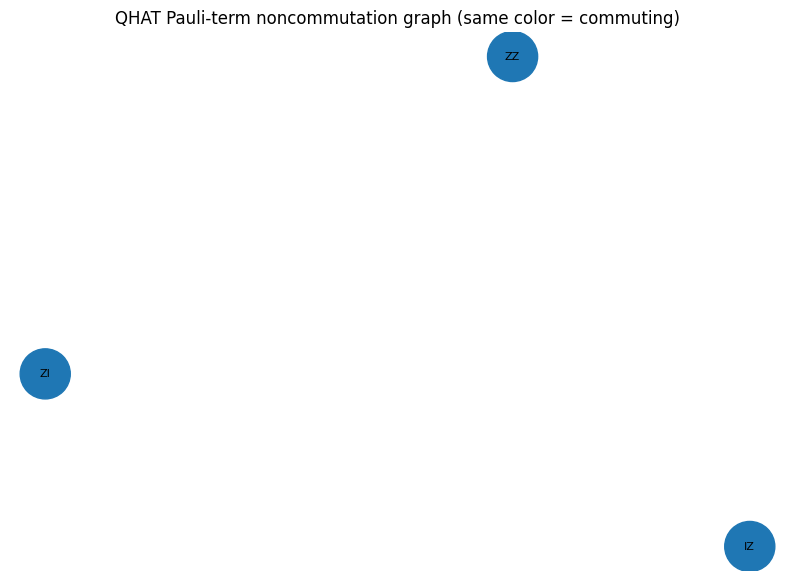

In [32]:
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=7)
palette = plt.cm.tab20
nx.draw_networkx(
    G, pos, labels={i: terms[i][0] for i in G},
    node_color=[palette(coloring[i] % 20) for i in G],
    node_size=1300, font_size=8, edge_color='0.65'
)
plt.title('QHAT Pauli-term noncommutation graph (same color = commuting)')
plt.axis('off'); plt.show()

## 5. Exact evolution and color-ordered Trotter error

We measure both spectral operator error $\lVert U_{PF}-e^{-iHt}\rVert_2$ and error on the Hartree–Fock computational-basis state. First order applies each commuting color block once per step. Second order uses the symmetric forward/reverse color-block ordering.

In [33]:
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
PAULI = {'I': I2, 'X': X, 'Y': Y, 'Z': Z}

def pauli_matrix(word):
    result = np.array([[1]], dtype=complex)
    for letter in word:
        result = np.kron(result, PAULI[letter])
    return result

matrices = [pauli_matrix(p) for p, _ in terms]
dimension = matrices[0].shape[0]
identity = np.eye(dimension, dtype=complex)
H = sum((c * P for (_, c), P in zip(terms, matrices)), np.zeros_like(identity))
identity_coefficient = sum(c for p, c in all_terms if set(p) == {'I'})
H_full = H + identity_coefficient * identity

def term_evolution(index, tau):
    c = terms[index][1]
    P = matrices[index]
    return np.cos(c * tau) * identity - 1j * np.sin(c * tau) * P

ordered_groups = [groups[color] for color in sorted(groups)]
def trotter_unitary(total_time, nsteps, order=1):
    dt = total_time / nsteps
    one_step = identity.copy()
    if order == 1:
        schedule = [(group, dt) for group in ordered_groups]
    elif order == 2:
        schedule = ([(group, dt/2) for group in ordered_groups] +
                    [(group, dt/2) for group in reversed(ordered_groups)])
    else:
        raise ValueError('order must be 1 or 2')
    for group, tau in schedule:
        for index in group:  # these exponentials commute within the color
            one_step = term_evolution(index, tau) @ one_step
    return np.linalg.matrix_power(one_step, nsteps)

TOTAL_TIME = 1.0
U_exact = expm(-1j * H * TOTAL_TIME)
n_qubits = int(round(np.log2(dimension)))
n_electrons = int(metadata.get('number of active, occupied, single-occupancy orbitals', 0))
hf_index = sum(1 << (n_qubits - 1 - q) for q in range(min(n_electrons, n_qubits)))
psi0 = np.zeros(dimension, dtype=complex); psi0[hf_index] = 1

error_rows = []
for order in (1, 2):
    for nsteps in (1, 2, 5, 10, 20, 50):
        U_pf = trotter_unitary(TOTAL_TIME, nsteps, order=order)
        error_rows.append({
            'order': order, 'steps': nsteps,
            'operator_spectral_error': norm(U_pf - U_exact, 2),
            'HF_state_error': norm((U_pf - U_exact) @ psi0),
        })
errors = pd.DataFrame(error_rows)
display(errors)

,order,steps,operator_spectral_error,HF_state_error
0,1,1,1.118863e-16,0.000000e+00
1,1,2,1.387779e-17,1.387779e-17
2,1,5,4.475452e-16,0.000000e+00
3,1,10,1.563208e-15,1.114465e-15
4,1,20,4.475452e-16,1.387779e-17
5,1,50,7.608269e-15,6.125515e-15
6,2,1,1.118863e-16,1.118863e-16
7,2,2,4.460365e-16,2.220446e-16
8,2,5,1.008792e-15,5.566706e-16
9,2,10,1.338110e-15,1.112389e-15


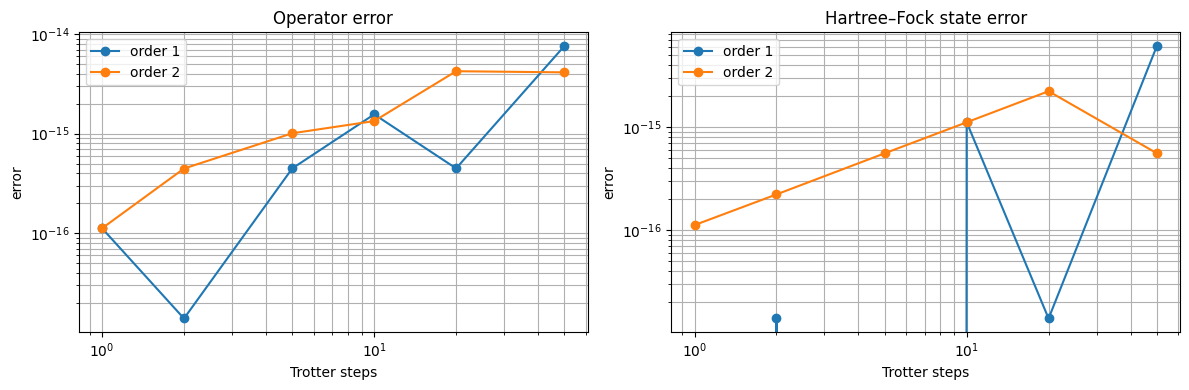

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for order, frame in errors.groupby('order'):
    axes[0].loglog(frame.steps, frame.operator_spectral_error, 'o-', label=f'order {order}')
    axes[1].loglog(frame.steps, frame.HF_state_error, 'o-', label=f'order {order}')
axes[0].set_title('Operator error'); axes[1].set_title('Hartree–Fock state error')
for ax in axes:
    ax.set_xlabel('Trotter steps'); ax.set_ylabel('error'); ax.grid(True, which='both'); ax.legend()
plt.tight_layout(); plt.show()

## 6. Reproduce the fermionic-coloring → JW-order comparison

This is the comparison made in `h2_fermionic.ipynb`: reconstruct Hermitian fermionic vertices from QHAT's tensors, color their noncommutation graph, map them through Jordan–Wigner, and retain the fermionic color order for the product formula. No OpenFermion import is used. Because JW is an algebra-preserving map, matrix commutators of the mapped vertices give the same fermionic commutation decisions.

Run the generation cell first: the checked-in fallback `.dat` does not include its tensor file. Select a generated **JW** file below.

In [35]:
# Optional selection across molecule, bond length, basis, and active space.
# Set a field to None to accept every value; the first matching JW file is used.
SELECT = {
    'molecule': 'H-H', 'L': None, 'basis': 'hgbs-5',
    'active_occupied': None, 'active_vacant': None,
}

if len(inventory):
    candidates = inventory[inventory.mapping.eq('jw')].copy()
    for field, value in SELECT.items():
        if value is not None:
            candidates = candidates[candidates[field].eq(value)]
    if len(candidates):
        FERMI_DAT = Path(candidates.sort_values(['qubits', 'L']).iloc[0].path)
    else:
        FERMI_DAT = None
        print('No generated JW file matches SELECT.')
else:
    FERMI_DAT = None
print('Fermionic comparison file:', FERMI_DAT)

Fermionic comparison file: /Users/albertlee0125/Repos/qhat/demo_L_sweep_library/H-H/0.51/hgbs-5/H-H_0.51_hgbs-5_as-002-002_jw.dat


In [36]:
def ladder_matrices(n_qubits):
    # JW: a_j = Z_0...Z_{j-1}(X_j+iY_j)/2.
    annihilation, creation = [], []
    for j in range(n_qubits):
        factors_a, factors_c = [], []
        for q in range(n_qubits):
            if q < j:
                factors_a.append(Z); factors_c.append(Z)
            elif q == j:
                factors_a.append((X + 1j*Y)/2)
                factors_c.append((X - 1j*Y)/2)
            else:
                factors_a.append(I2); factors_c.append(I2)
        def kron_all(items):
            out = np.array([[1]], dtype=complex)
            for item in items: out = np.kron(out, item)
            return out
        annihilation.append(kron_all(factors_a))
        creation.append(kron_all(factors_c))
    return annihilation, creation

def monomial_matrix(key, annihilation, creation):
    dim = annihilation[0].shape[0]
    out = np.eye(dim, dtype=complex)
    for mode, action in key:
        out = out @ (creation[mode] if action else annihilation[mode])
    return out

def canonicalize_tensor_monomial(key):
    # QHAT tensor terms already have creations before annihilations. Match
    # OpenFermion normal_ordered by sorting both groups in descending mode order.
    actions = [action for _, action in key]
    ncre = sum(action == 1 for action in actions)
    if actions != [1]*ncre + [0]*(len(actions)-ncre):
        raise ValueError(f'Tensor monomial is not normal ordered: {key}')
    creators = [mode for mode, action in key if action == 1]
    annihilators = [mode for mode, action in key if action == 0]
    if len(set(creators)) < len(creators) or len(set(annihilators)) < len(annihilators):
        return None, 0
    swaps = sum(values[i] < values[j] for values in (creators, annihilators)
                for i in range(len(values)) for j in range(i+1, len(values)))
    canonical = (tuple((mode,1) for mode in sorted(creators, reverse=True)) +
                 tuple((mode,0) for mode in sorted(annihilators, reverse=True)))
    return canonical, (-1 if swaps % 2 else 1)

def dagger_key(key):
    canonical, sign = canonicalize_tensor_monomial(
        tuple((mode, 1-action) for mode, action in reversed(key))
    )
    if canonical is None or sign != 1:
        raise ValueError(f'Unexpected dagger canonicalization for {key}')
    return canonical

def tensor_monomials(tensor_file, tol=1e-12):
    with np.load(tensor_file) as data:
        constant = complex(data['constant']) if 'constant' in data.files else 0.0
        one, two = data['one_body'], data['two_body']
    coeffs = {}
    def accumulate(key, coefficient):
        canonical, sign = canonicalize_tensor_monomial(key)
        if canonical is not None:
            coeffs[canonical] = coeffs.get(canonical, 0.0) + sign*coefficient
    accumulate((), constant)
    for p, q in np.argwhere(np.abs(one) > tol):
        accumulate(((int(p),1),(int(q),0)), complex(one[p,q]))
    for p, q, r, s in np.argwhere(np.abs(two) > tol):
        accumulate(((int(p),1),(int(q),1),(int(r),0),(int(s),0)), complex(two[p,q,r,s]))
    coeffs = {key: coeff for key, coeff in coeffs.items() if abs(coeff) > tol}
    return coeffs, one.shape[0]

def hermitian_vertices_from_tensors(tensor_file, tol=1e-12):
    coeffs, n_qubits = tensor_monomials(tensor_file, tol)
    annihilation, creation = ladder_matrices(n_qubits)
    used, vertices, labels = set(), [], []
    for key, coefficient in coeffs.items():
        if key in used: continue
        partner = dagger_key(key)
        M = monomial_matrix(key, annihilation, creation) if key else np.eye(2**n_qubits)
        if partner == key:
            T = coefficient * M; used.add(key)
        else:
            partner_coefficient = coeffs.get(partner, 0.0)
            Md = monomial_matrix(partner, annihilation, creation)
            T = coefficient * M + partner_coefficient * Md
            used.update((key, partner))
        if norm(T, 2) > tol:
            vertices.append(T); labels.append((key, partner))
    return vertices, labels, n_qubits

def matrix_noncommutation_graph(vertices, tol=1e-10):
    graph = nx.Graph(); graph.add_nodes_from(range(len(vertices)))
    for i in range(len(vertices)):
        for j in range(i+1, len(vertices)):
            if norm(vertices[i] @ vertices[j] - vertices[j] @ vertices[i], 2) > tol:
                graph.add_edge(i, j)
    colors = nx.coloring.greedy_color(graph, strategy='largest_first')
    color_groups = {}
    for node, color in colors.items(): color_groups.setdefault(color, []).append(node)
    return graph, colors, color_groups

if FERMI_DAT is not None:
    FERMI_TENSORS = tensor_path_for_dat(FERMI_DAT)
    fermion_vertices, fermion_labels, fermion_nq = hermitian_vertices_from_tensors(FERMI_TENSORS)
    FG, fermion_coloring, fermion_groups = matrix_noncommutation_graph(fermion_vertices)
    fm, fterms = parse_qhat_dat(FERMI_DAT)
    H_dat = sum((c*pauli_matrix(p) for p,c in fterms), np.zeros_like(fermion_vertices[0]))
    H_tensor = sum(fermion_vertices, np.zeros_like(fermion_vertices[0]))
    reconstruction_error = norm(H_tensor - H_dat, 2)
    print('Hermitian fermionic vertices:', len(fermion_vertices))
    print('Fermionic noncommutation edges:', FG.number_of_edges())
    print('Fermionic commuting colors:', len(fermion_groups))
    print('Tensor → JW `.dat` reconstruction error:', reconstruction_error)
    if reconstruction_error > 1e-8:
        print('WARNING: tensor convention/order does not match this `.dat`; do not interpret the comparison yet.')
else:
    print('Generate/select a JW file to run this section.')

Hermitian fermionic vertices: 23
Fermionic noncommutation edges: 32
Fermionic commuting colors: 2
Tensor → JW `.dat` reconstruction error: 5.551115123125783e-16


In [37]:
def product_formula_from_groups(vertices, color_groups, total_time, nsteps, order):
    dim = vertices[0].shape[0]; eye = np.eye(dim, dtype=complex)
    dt = total_time/nsteps
    ordered = [color_groups[c] for c in sorted(color_groups)]
    if order == 1:
        schedule = [(group, dt) for group in ordered]
    else:
        schedule = ([(group, dt/2) for group in ordered] +
                    [(group, dt/2) for group in reversed(ordered)])
    step = eye.copy()
    for group, tau in schedule:
        for index in group:
            step = expm(-1j*tau*vertices[index]) @ step
    return np.linalg.matrix_power(step, nsteps)

if FERMI_DAT is not None and reconstruction_error < 1e-8:
    # Pauli vertices from the same selected QHAT file.
    # Retain the identity here so both decompositions carry the same global phase.
    pauli_vertices = [c*pauli_matrix(p) for p,c in fterms]
    PG, pauli_colors, pauli_groups = matrix_noncommutation_graph(pauli_vertices)
    U_ref = expm(-1j*H_dat*TOTAL_TIME)
    comparison_rows = []
    for scheme, vertices, color_groups in [
        ('fermionic coloring mapped to JW', fermion_vertices, fermion_groups),
        ('direct JW Pauli coloring', pauli_vertices, pauli_groups),
    ]:
        for order in (1, 2):
            for steps in (1, 2, 5, 10):
                U = product_formula_from_groups(vertices, color_groups, TOTAL_TIME, steps, order)
                comparison_rows.append({
                    'scheme': scheme, 'colors': len(color_groups),
                    'order': order, 'steps': steps, 'spectral_error': norm(U-U_ref, 2),
                })
    coloring_comparison = pd.DataFrame(comparison_rows)
    display(coloring_comparison)
else:
    print('Comparison skipped until a validated generated JW/tensor pair is selected.')

,scheme,colors,order,steps,spectral_error
0,fermionic coloring mapped to JW,2,1,1,0.011303
1,fermionic coloring mapped to JW,2,1,2,0.005498
2,fermionic coloring mapped to JW,2,1,5,0.002183
3,fermionic coloring mapped to JW,2,1,10,0.001090
4,fermionic coloring mapped to JW,2,2,1,0.002985
5,fermionic coloring mapped to JW,2,2,2,0.000722
6,fermionic coloring mapped to JW,2,2,5,0.000115
7,fermionic coloring mapped to JW,2,2,10,0.000029
8,direct JW Pauli coloring,2,1,1,0.011303
9,direct JW Pauli coloring,2,1,2,0.005498


## 7. Batch graph metrics across molecules and active spaces

This lightweight batch pass avoids dense evolution matrices. It works for every generated JW or BK `.dat` file and reports graph structure across bond lengths, bases, mappings, and active spaces. Filter the result before attempting dense Trotter-error calculations.

In [38]:
def pauli_graph_metrics(path):
    meta, parsed = parse_qhat_dat(path)
    words = [p for p,c in parsed if set(p) != {'I'} and abs(c) > 0]
    edges = sum(not paulis_commute(words[i], words[j])
                for i in range(len(words)) for j in range(i+1, len(words)))
    graph = nx.Graph(); graph.add_nodes_from(range(len(words)))
    graph.add_edges_from((i,j) for i in range(len(words)) for j in range(i+1,len(words))
                         if not paulis_commute(words[i], words[j]))
    colors = nx.coloring.greedy_color(graph, strategy='largest_first')
    return len(words), edges, (max(colors.values())+1 if colors else 0)

batch_rows = []
for row in inventory.itertuples():
    nterms, nedges, ncolors = pauli_graph_metrics(row.path)
    batch_rows.append({
        'molecule': row.molecule, 'L': row.L, 'basis': row.basis,
        'occupied': row.active_occupied, 'vacant': row.active_vacant,
        'qubits': row.qubits, 'mapping': row.mapping,
        'Pauli_terms': nterms, 'noncommuting_edges': nedges, 'colors': ncolors,
    })
batch_summary = pd.DataFrame(batch_rows)
display(batch_summary if len(batch_summary) else pd.DataFrame({'status':['Generate the sweep first']}))

,molecule,L,basis,occupied,vacant,qubits,mapping,Pauli_terms,noncommuting_edges,colors
0,B-B,1.36,hgbs-5,2,2,4,bk,14,16,2
1,B-B,1.36,hgbs-5,2,2,4,jw,14,16,2
2,B-B,1.36,hgbs-5,2,4,6,bk,33,168,3
3,B-B,1.36,hgbs-5,2,4,6,jw,33,168,3
4,B-B,1.36,hgbs-5,4,4,8,bk,60,576,4
...,...,...,...,...,...,...,...,...,...,...
301,Li-Li,3.72,sto-6g,2,2,4,jw,14,16,2
302,Li-Li,3.72,sto-6g,2,4,6,bk,61,760,6
303,Li-Li,3.72,sto-6g,2,4,6,jw,61,760,6
304,Li-Li,3.72,sto-6g,4,4,8,bk,192,7956,17


## 8. Full-library Trotter-error case study

This runner applies the same two decompositions to every generated **JW** case:

- Hermitian fermionic vertices from `.tensors.npz` → fermionic noncommutation colors → JW matrices;
- individual JW Pauli strings from `.dat` → Pauli noncommutation colors.

It spans all selected molecules, bond lengths, bases, and active spaces. Exact dense evolution is exponential, so `CASE_MAX_QUBITS` is a deliberate safety control rather than a restriction on generation. Set `RUN_ALL_CASE_STUDIES=True` after the sweep finishes. Results are retained in `case_results` and can optionally be saved as CSV.

In [39]:
RUN_ALL_CASE_STUDIES = True
CASE_MAX_QUBITS = 6       # populated dense study; all larger cases remain in graph tables
CASE_ORDERS = (1, 2)
CASE_STEPS = (1, 2, 5, 10)
CASE_TOTAL_TIME = 1.0
SAVE_CASE_RESULTS = True
CASE_RESULTS_CSV = REPO / 'qhat_full_library_coloring_trotter_errors.csv'

def analyze_coloring_case(dat_path, total_time=1.0, orders=(1,2), steps_list=(1,2,5,10)):
    dat_path = Path(dat_path)
    tensor_path = tensor_path_for_dat(dat_path)
    if not tensor_path.exists():
        raise FileNotFoundError(f'Missing tensor file: {tensor_path}')

    meta, mapped_terms = parse_qhat_dat(dat_path)
    fvertices, _, nqubits = hermitian_vertices_from_tensors(tensor_path)
    FG, _, fgroups = matrix_noncommutation_graph(fvertices)
    pvertices = [c*pauli_matrix(p) for p,c in mapped_terms]
    PG, _, pgroups = matrix_noncommutation_graph(pvertices)

    zero = np.zeros_like(fvertices[0])
    Hf_jw = sum(fvertices, zero.copy())
    Hdat = sum(pvertices, zero.copy())
    validation_error = norm(Hf_jw-Hdat, 2)
    if validation_error > 1e-8:
        raise ValueError(f'Tensor/JW reconstruction error {validation_error:.3e}')
    Uexact = expm(-1j*total_time*Hdat)

    output = []
    decompositions = (
        ('fermionic_commutation_then_JW', fvertices, fgroups, FG),
        ('JW_Pauli_string_commutation', pvertices, pgroups, PG),
    )
    for scheme, vertices, groups_for_scheme, graph in decompositions:
        for order in orders:
            for steps in steps_list:
                Upf = product_formula_from_groups(
                    vertices, groups_for_scheme, total_time, steps, order
                )
                output.append({
                    'scheme': scheme, 'vertices': len(vertices),
                    'noncommuting_edges': graph.number_of_edges(),
                    'colors': len(groups_for_scheme), 'order': order, 'steps': steps,
                    'spectral_error': norm(Upf-Uexact, 2),
                    'reconstruction_error': validation_error,
                })
    return output

case_rows, skipped_rows = [], []
eligible = inventory[(inventory.mapping == 'jw') & (inventory.qubits <= CASE_MAX_QUBITS)].copy() \
    if len(inventory) else pd.DataFrame()
if RUN_ALL_CASE_STUDIES:
    for case_number, row in enumerate(eligible.itertuples(), start=1):
        case_id = (row.molecule, row.L, row.basis, row.active_occupied, row.active_vacant)
        print(f'[{case_number}/{len(eligible)}] {case_id}')
        try:
            measurements = analyze_coloring_case(
                row.path, CASE_TOTAL_TIME, CASE_ORDERS, CASE_STEPS
            )
            for measurement in measurements:
                case_rows.append({
                    'molecule': row.molecule, 'L': row.L, 'basis': row.basis,
                    'active_occupied': row.active_occupied,
                    'active_vacant': row.active_vacant, 'qubits': row.qubits,
                    **measurement, 'file': str(row.path),
                })
        except Exception as exc:
            skipped_rows.append({'case': case_id, 'reason': str(exc)})
    case_results = pd.DataFrame(case_rows)
    skipped_cases = pd.DataFrame(skipped_rows)
    if SAVE_CASE_RESULTS and len(case_results):
        case_results.to_csv(CASE_RESULTS_CSV, index=False)
        print('Saved:', CASE_RESULTS_CSV)
    display(case_results)
    if len(skipped_cases):
        print('Skipped cases:'); display(skipped_cases)
else:
    case_results = pd.DataFrame()
    skipped_cases = pd.DataFrame()
    print(f'{len(eligible)} generated JW cases are eligible at <= {CASE_MAX_QUBITS} qubits.')
    print('Set RUN_ALL_CASE_STUDIES=True to calculate their exact Trotter errors.')

[1/108] ('B-B', 1.36, 'hgbs-5', 2, 2)
[2/108] ('B-B', 1.36, 'hgbs-5', 2, 4)
[3/108] ('B-B', 1.36, 'sto-6g', 2, 2)
[4/108] ('B-B', 1.36, 'sto-6g', 2, 4)
[5/108] ('B-B', 1.87, 'hgbs-5', 2, 2)
[6/108] ('B-B', 1.87, 'hgbs-5', 2, 4)
[7/108] ('B-B', 1.87, 'sto-6g', 2, 2)
[8/108] ('B-B', 1.87, 'sto-6g', 2, 4)
[9/108] ('B-B', 2.38, 'hgbs-5', 2, 2)
[10/108] ('B-B', 2.38, 'hgbs-5', 2, 4)
[11/108] ('B-B', 2.38, 'sto-6g', 2, 2)
[12/108] ('B-B', 2.38, 'sto-6g', 2, 4)
[13/108] ('B-H', 0.94, 'hgbs-5', 2, 2)
[14/108] ('B-H', 0.94, 'hgbs-5', 2, 4)
[15/108] ('B-H', 0.94, 'sto-6g', 2, 2)
[16/108] ('B-H', 0.94, 'sto-6g', 2, 4)
[17/108] ('B-H', 1.29, 'hgbs-5', 2, 2)
[18/108] ('B-H', 1.29, 'hgbs-5', 2, 4)
[19/108] ('B-H', 1.29, 'sto-6g', 2, 2)
[20/108] ('B-H', 1.29, 'sto-6g', 2, 4)
[21/108] ('B-H', 1.64, 'hgbs-5', 2, 2)
[22/108] ('B-H', 1.64, 'hgbs-5', 2, 4)
[23/108] ('B-H', 1.64, 'sto-6g', 2, 2)
[24/108] ('B-H', 1.64, 'sto-6g', 2, 4)
[25/108] ('Be-Be', 1.63, 'hgbs-5', 2, 2)
[26/108] ('Be-Be', 1.63, 'hgbs-5

,molecule,L,basis,active_occupied,active_vacant,qubits,scheme,vertices,noncommuting_edges,colors,order,steps,spectral_error,reconstruction_error,file
0,B-B,1.36,hgbs-5,2,2,4,fermionic_commutation_then_JW,23,32,2,1,1,0.007830,1.421085e-14,/Users/albertlee0125/Repos/qhat/demo_L_sweep_l...
1,B-B,1.36,hgbs-5,2,2,4,fermionic_commutation_then_JW,23,32,2,1,2,0.003913,1.421085e-14,/Users/albertlee0125/Repos/qhat/demo_L_sweep_l...
2,B-B,1.36,hgbs-5,2,2,4,fermionic_commutation_then_JW,23,32,2,1,5,0.001565,1.421085e-14,/Users/albertlee0125/Repos/qhat/demo_L_sweep_l...
3,B-B,1.36,hgbs-5,2,2,4,fermionic_commutation_then_JW,23,32,2,1,10,0.000782,1.421085e-14,/Users/albertlee0125/Repos/qhat/demo_L_sweep_l...
4,B-B,1.36,hgbs-5,2,2,4,fermionic_commutation_then_JW,23,32,2,2,1,0.000243,1.421085e-14,/Users/albertlee0125/Repos/qhat/demo_L_sweep_l...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1723,Li-Li,3.72,sto-6g,2,4,6,JW_Pauli_string_commutation,62,760,6,1,10,0.004343,5.329136e-15,/Users/albertlee0125/Repos/qhat/demo_L_sweep_l...
1724,Li-Li,3.72,sto-6g,2,4,6,JW_Pauli_string_commutation,62,760,6,2,1,0.002800,5.329136e-15,/Users/albertlee0125/Repos/qhat/demo_L_sweep_l...
1725,Li-Li,3.72,sto-6g,2,4,6,JW_Pauli_string_commutation,62,760,6,2,2,0.000704,5.329136e-15,/Users/albertlee0125/Repos/qhat/demo_L_sweep_l...
1726,Li-Li,3.72,sto-6g,2,4,6,JW_Pauli_string_commutation,62,760,6,2,5,0.000113,5.329136e-15,/Users/albertlee0125/Repos/qhat/demo_L_sweep_l...


,basis,qubits,scheme,order,steps,cases,median_error,mean_error,max_error,median_colors
0,hgbs-5,2,JW_Pauli_string_commutation,1,1,6,5.360936e-16,5.529663e-16,1.180183e-15,1.0
1,hgbs-5,2,JW_Pauli_string_commutation,1,2,6,6.980280e-16,6.767775e-16,1.336886e-15,1.0
2,hgbs-5,2,JW_Pauli_string_commutation,1,5,6,1.113668e-15,1.324270e-15,2.248030e-15,1.0
3,hgbs-5,2,JW_Pauli_string_commutation,1,10,6,1.361223e-15,1.652709e-15,3.096706e-15,1.0
4,hgbs-5,2,JW_Pauli_string_commutation,2,1,6,5.574745e-16,6.263891e-16,1.421779e-15,1.0
...,...,...,...,...,...,...,...,...,...,...
91,sto-6g,6,fermionic_commutation_then_JW,1,10,18,4.304081e-03,6.956530e-03,2.430354e-02,4.0
92,sto-6g,6,fermionic_commutation_then_JW,2,1,18,6.724865e-03,1.594137e-02,5.304343e-02,4.0
93,sto-6g,6,fermionic_commutation_then_JW,2,2,18,1.713808e-03,4.235549e-03,1.387240e-02,4.0
94,sto-6g,6,fermionic_commutation_then_JW,2,5,18,2.756801e-04,6.892733e-04,2.247401e-03,4.0


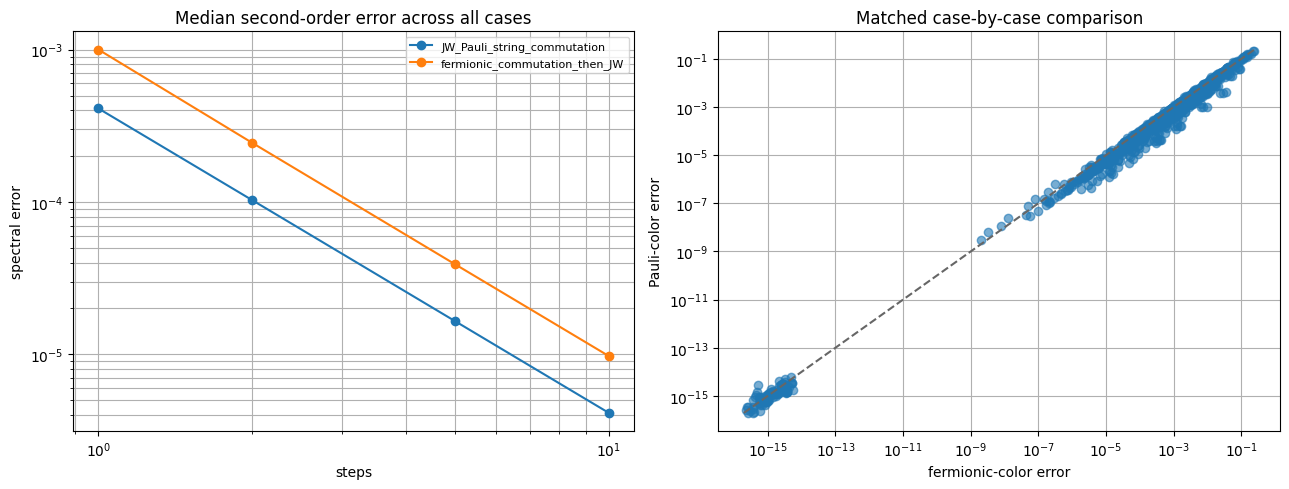

In [40]:
# Side-by-side aggregate comparison across every completed case.
if len(case_results):
    aggregate = (case_results
        .groupby(['basis','qubits','scheme','order','steps'], as_index=False)
        .agg(cases=('spectral_error','size'),
             median_error=('spectral_error','median'),
             mean_error=('spectral_error','mean'),
             max_error=('spectral_error','max'),
             median_colors=('colors','median')))
    display(aggregate)

    plot_data = case_results[case_results.order.eq(2)]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for scheme, frame in plot_data.groupby('scheme'):
        curve = frame.groupby('steps').spectral_error.median()
        axes[0].loglog(curve.index, curve.values, 'o-', label=scheme)
    axes[0].set_title('Median second-order error across all cases')
    axes[0].set_xlabel('steps'); axes[0].set_ylabel('spectral error')
    axes[0].grid(True, which='both'); axes[0].legend(fontsize=8)

    paired = case_results.pivot_table(
        index=['molecule','L','basis','active_occupied','active_vacant','order','steps'],
        columns='scheme', values='spectral_error'
    ).dropna()
    x = paired['fermionic_commutation_then_JW']
    y = paired['JW_Pauli_string_commutation']
    axes[1].loglog(x, y, 'o', alpha=0.6)
    limits = [min(x.min(),y.min()), max(x.max(),y.max())]
    axes[1].plot(limits, limits, '--', color='0.4')
    axes[1].set_xlabel('fermionic-color error'); axes[1].set_ylabel('Pauli-color error')
    axes[1].set_title('Matched case-by-case comparison')
    axes[1].grid(True, which='both')
    plt.tight_layout(); plt.show()
else:
    print('Run the full-library case-study cell to populate aggregate comparisons.')

## Scaling to many active spaces and molecules

Use the `inventory` table to select or loop over files. Graph construction is inexpensive for moderate Pauli-term counts, but this notebook intentionally uses dense matrices for transparent error validation, so keep selected Hamiltonians near 10 qubits or fewer. For larger active spaces, use `julia_trotter/trotter_expts.jl` or its sparse/matrix-free routines.

Also note that QHAT's active occupied/vacant counts are spin-orbital counts, and their sum is the qubit count before any possible symmetry reduction.

## Focused benchmark: why the two colorings differ

The repository-level benchmark selects the three representative cases requested in `next_step.md`, evaluates first- and second-order formulas at 1, 2, 5, and 10 steps, and samples 100 random vertex orderings per method. It also records color-block commutator norms, nested commutator norms, and particle-number leakage for the QHAT Hartree–Fock state.

Regenerate the data with:

```bash
python run_trotter_benchmark.py --random-orderings 100
python summarize_trotter_results.py
```

The following cells are a compact explorer for the generated CSV files. The sampled best ordering is evidence from the 100 trials, not a global optimum.

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:  # Lets the cell remain usable in a plain Python environment.
    display = print

benchmark_dir = Path('trotter_benchmark_results')
if not benchmark_dir.exists():
    raise FileNotFoundError(
        'Run run_trotter_benchmark.py and summarize_trotter_results.py first.'
    )

benchmark_graphs = pd.read_csv(benchmark_dir / 'graph_diagnostics.csv')
benchmark_robustness = pd.read_csv(benchmark_dir / 'robustness_summary.csv')
benchmark_blocks = pd.read_csv(benchmark_dir / 'block_commutators.csv')
benchmark_trials = pd.read_csv(benchmark_dir / 'ordering_trials.csv')

scheme_names = {
    'fermionic_commutation_then_JW': 'Fermionic coloring → JW',
    'JW_Pauli_string_commutation': 'Direct JW Pauli coloring',
}

graph_view = benchmark_graphs[[
    'case_id', 'molecule', 'bond_length', 'basis', 'qubits', 'scheme',
    'vertices', 'noncommuting_edges', 'colors',
    'block_commutator_norm_sum', 'ordered_commutator_sum_norm',
    'nested_commutator_norm_sum',
]].copy()
graph_view['scheme'] = graph_view['scheme'].map(scheme_names)
display(graph_view)

step10_view = benchmark_robustness.query('steps == 10')[[
    'case_id', 'basis', 'scheme', 'formula_order', 'colored_error',
    'random_best_observed_error', 'random_median_error',
    'colored_over_global_best', 'fraction_random_better_than_colored',
    'colored_particle_number_leakage',
    'random_median_particle_number_leakage',
]].copy()
step10_view['scheme'] = step10_view['scheme'].map(scheme_names)
display(step10_view)

In [ ]:
# Solid lines are deterministic colored schedules; dashed lines are random medians.
case_order = ['similar_4q', 'fermionic_first_order_6q', 'jw_second_order_6q']
fig, axes = plt.subplots(len(case_order), 2, figsize=(13, 12), sharex=True)

for row, case_id in enumerate(case_order):
    for col, formula_order in enumerate([1, 2]):
        ax = axes[row, col]
        frame = benchmark_robustness.query(
            'case_id == @case_id and formula_order == @formula_order'
        )
        for scheme, group in frame.groupby('scheme'):
            group = group.sort_values('steps')
            label = scheme_names[scheme]
            line, = ax.loglog(group.steps, group.colored_error, 'o-', label=label)
            ax.loglog(
                group.steps, group.random_median_error, 's--',
                color=line.get_color(), alpha=0.75, label=f'{label}: random median',
            )
            ax.fill_between(
                group.steps, group.random_p10_error, group.random_p90_error,
                color=line.get_color(), alpha=0.12,
            )
        basis = frame.basis.iloc[0]
        ax.set_title(f'{case_id} ({basis}), order {formula_order}')
        ax.set_xlabel('Trotter steps')
        ax.set_ylabel('spectral error')
        ax.grid(True, which='both', alpha=0.3)
        if row == 0 and col == 0:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### What this adds

1. **Topology is not enough.** The two six-qubit B–B cases have the same geometry, active space, graph counts, and color memberships, but changing STO-6G to HGBS-5 reverses the preferred method. The Hamiltonian coefficients change the block and nested commutators even when the unweighted graph does not.
2. **Canonical terms matter.** Normal-order aggregation reduces the selected four-qubit fermionic graph from 23 vertices/32 edges to 13/12 and the selected six-qubit graphs from 55/360 to 28/90. The three colored errors do not change because the duplicate tensor permutations were in the same blocks, but random-order statistics do change. Raw tensor slots are therefore not meaningful graph vertices.
3. **Nested commutators help explain second order.** Their summed norms are larger for the method with the larger second-order error in both six-qubit examples. This supports a coefficient-aware explanation, although three cases do not establish a universal predictor.
4. **A coloring is not automatically a good ordering.** In several rows, most random permutations beat the deterministic greedy colored schedule. The random median and percentile band reveal this fragility.
5. **The fermionic decomposition has a number-conservation advantage.** Complete fermionic vertices preserve particle number under every sampled order. Random individual JW Pauli-string orders can split cancellation partners and produce measurable leakage, while an appropriate colored JW schedule can suppress it. Here the leakage is much smaller than the spectral error, so treat it as a robustness diagnostic rather than the main error source.

See `trotter_benchmark_results/benchmark_summary.md` for the numeric tables and scope limits.